In [1]:
import numpy as np
import torch.nn as nn
from tqdm import tqdm
from torch.distributions.multivariate_normal import MultivariateNormal
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

[Errno 2] No such file or directory: 'None'
/Users/antonioalvarezlopez/Desktop/Coding/GPMix


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [2]:
B = 16 # Batch size
T = 10 # Number of timesteps
F = 12 # Numbers of features
K = 3 # Number of mixture components
r = 128 # Estimate the covariance matrix
R = 50 # Number of eigenvalues
dt = 1/(T-1)
ts = torch.linspace(0, 1, T)
#X = torch.randn((B, T)) #torch.randn((B, T, F))

lr = 0.1
lambd_reg = 1e-5

sigma = 10 # Functional RBF
alpha=-1/(2*sigma**2)

sigmas = np.array([1, 0.3, 2]) # Mixture model data
assert len(sigmas)==K

In [3]:
def rbf_fkernel(x1, x2, dt, alpha=-1.0): # (B, T, F)
    y = dt*torch.square(x1-x2) #.sum(-1) # (B, T)
    norm = (y[..., 0] / 2 + y[..., 1:-1].sum(dim=-1) + y[..., -1] / 2)
    return torch.exp(alpha*norm)

def rbf_kernel(x1, x2, sigma): # (B, F) or (B)
    norm = torch.square(x1-x2) #.sum(-1) # (B, T)
    return torch.exp(-1/(2*sigma**2)*norm)

In [4]:
t1, t2 = ts[:, None], ts[None, :]

num = np.array([200, 100, 20]) # Num samples for dataset
X1 = MultivariateNormal(5*torch.sin(2*ts), 3*rbf_kernel(t1, t2, sigma=1) + 1e-5 * torch.eye(T)).sample((num[0],))
X2 = MultivariateNormal(torch.zeros(T), rbf_kernel(t1, t2, sigma=0.3) + 1e-5 * torch.eye(T)).sample((num[1],))
X3 = MultivariateNormal(10*torch.cos(4*ts), rbf_kernel(t1, t2, sigma=2) + 1e-5 * torch.eye(T)).sample((num[2],))
Xs = [X1, X2, X3]
X = torch.concatenate(Xs, dim=0)

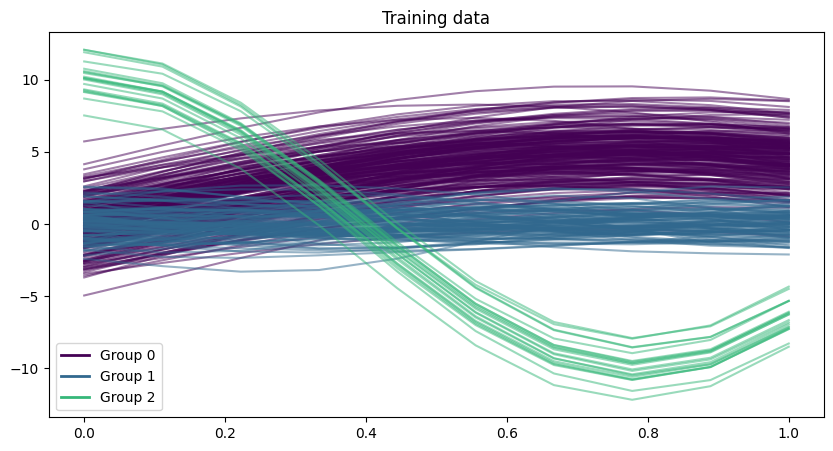

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = mpl.colormaps.get_cmap('viridis')
for i in range(len(Xs)):
    ax.plot(ts, Xs[i].detach().numpy().T, alpha=0.5, color=cmap(i/len(Xs)))

legend_elements = [Line2D([0], [0], color=cmap(i/len(Xs)), lw=2, label=f'Group {i}') 
                   for i in range(len(Xs))]
ax.legend(handles=legend_elements)
ax.set_title("Training data")
plt.show()

In [6]:
m = torch.randn((K,T)) #torch.randn((K, F))
pi = torch.full((K,), 1/K)

kernels = [lambda x1, x2, s=s: rbf_kernel(x1, x2, sigma=s) for s in sigmas]

In [7]:
K_mat = torch.stack([kernel(t1, t2) for kernel in kernels]) * dt # [2 x 100 x 100]

evals, evecs = torch.linalg.eigh(K_mat)
# eigh returns eigenvalues in ascending order, so take the last R
evals, evecs = evals[..., -R:], evecs[..., -R:]
evals, evecs = torch.flip(evals, dims=[-1]), torch.flip(evecs, dims=[-1])

In [8]:
def MMD(X, m, pi, evals, evecs, alpha):
    """
    X: [B, T]
    m: [K, T]
    evals: [K, R]
    evecs: [K, T, R]
    K_math: [K, T, T]
    """
    # E1
    E1 = torch.mean(rbf_fkernel(X[None, :, :], X[:, None, :], dt, alpha=alpha))

    # E2
    p1 = 1/torch.sqrt(torch.prod(1 - 2*alpha*evals, dim=-1)) # [K]
    a1 = X[:, None, :] - m[None, :, :] # [B, K, T]
    b1 = torch.square(torch.sum(a1[..., None] * evecs[None], dim=2)*dt) # [B, K, R] # TODO
    c1 = b1 / (1-2*alpha*evals[None]) # [B, K, R]
    d1 = torch.mean(torch.exp(alpha*torch.sum(c1, dim=-1)), dim=0)
    E2 = torch.sum(pi*(p1*d1))

    # E3
    p2 = 1/torch.sqrt(torch.prod(1 - 2*alpha*(evals[None, :, :] + evals[:, None, :]),dim=-1))
    a2 = (m[None, :, :] - m[:, None, :])
    b2 = (evecs[None, :] + evecs[:, None])
    c2 = torch.square(torch.sum(a2[..., None] * b2, dim=2)*dt)
    d2 = c2 / (1-2*alpha*(evals[None, :, :] + evals[:, None, :])) 
    e2 = torch.exp(alpha*torch.sum(d2, dim=-1))
    E3 = torch.sum(torch.outer(pi, pi)*p2*e2)
    
    return E1, E2, E3

In [9]:
from sklearn.cluster import KMeans

# K-means en los datos para inicializar medias
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(X.detach().numpy())
m = nn.Parameter(torch.tensor(kmeans.cluster_centers_, dtype=torch.float32))
pi = nn.Parameter(torch.tensor(np.bincount(kmeans.labels_, minlength=K) / len(X), dtype=torch.float32))

pi = nn.Parameter(torch.full((K,), 1/K))
MMD(X, m, pi, evals, evecs, alpha=alpha)

(tensor(0.9128),
 tensor(0.9718, grad_fn=<SumBackward0>),
 tensor(0.8973, grad_fn=<SumBackward0>))

In [10]:
optimizer = torch.optim.Adam([m, pi], lr=0.01)
pbar = tqdm(range(1000))
for i in pbar:
    optimizer.zero_grad()
    
    E1, E2, E3 = MMD(X, m, pi, evals, evecs, alpha=alpha)
    loss_reg = torch.sum(m.square(), axis=0).sum()*dt

    loss = (E1 - 2*E2 + E3) + loss_reg*lambd_reg
    loss.backward()
    optimizer.step()
    pi.data.clamp_(0.,1.)
    pi.data /= 1e-7+torch.sum(pi.data)
    pbar.set_description(f"Total loss: {loss.item():.4f}, E1: {E1.item():.4f}, E2: {E2.item():.4f}, E3: {E3.item():.4f}, loss_reg: {loss_reg.item():.4f}")

Total loss: -0.3184, E1: 0.9128, E2: 0.9045, E3: 0.5728, loss_reg: 499.4470: 100%|██████████| 1000/1000 [00:04<00:00, 203.68it/s]


In [11]:
estimated_pi = pi.detach().numpy()
print("Estimated pi: ", estimated_pi)
print("True pi: ", num/np.sum(num))

Estimated pi:  [0.33367857 0.31921482 0.34710658]
True pi:  [0.625  0.3125 0.0625]


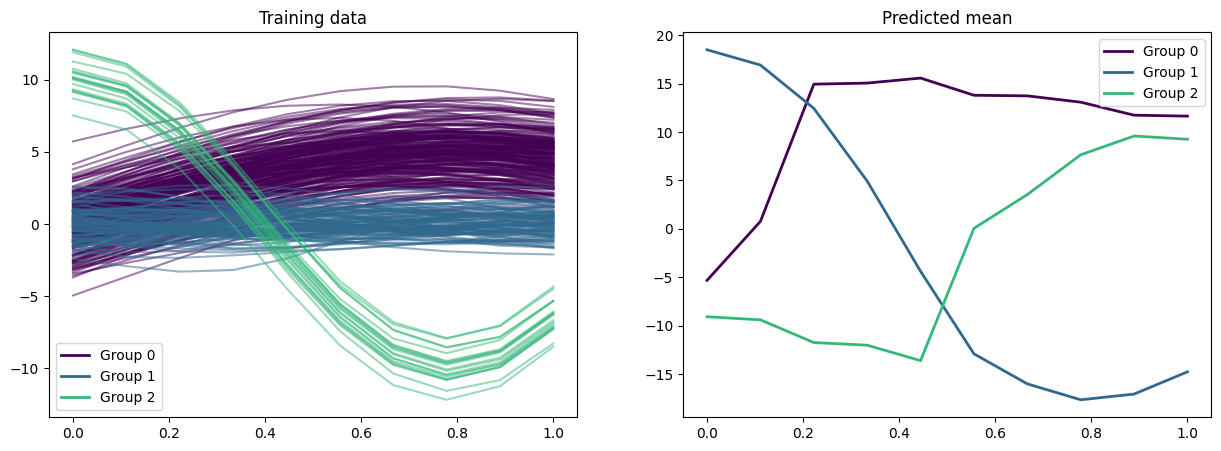

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15, 5))
cmap = mpl.colormaps.get_cmap('viridis')
for i in range(len(Xs)):
    ax1.plot(ts, Xs[i].detach().numpy().T, alpha=0.5, color=cmap(i/len(Xs)))

legend_elements = [Line2D([0], [0], color=cmap(i/len(Xs)), lw=2, label=f'Group {i}') 
                   for i in range(len(Xs))]
ax1.legend(handles=legend_elements)
ax1.set_title("Training data")

for i in range(K):
    ax2.plot(ts, m[i].detach().numpy(), color=cmap(i/K), lw=2, label=f'Group {i}')
ax2.legend()
ax2.set_title("Predicted mean")
plt.show()

## Test that Empirical MMD is the samme as Calculated

In [13]:
_m = nn.Parameter(torch.randn((K,T)))
_pi = nn.Parameter(torch.full((K,), 1/K))

In [14]:
x1 = MultivariateNormal(torch.zeros(T), rbf_kernel(t1, t2, sigma=sigmas[0]) + 1e-5 * torch.eye(T)).sample((900,))
x2 = MultivariateNormal(2*torch.ones(T), rbf_kernel(t1, t2, sigma=sigmas[1]) + 1e-5 * torch.eye(T)).sample((900,))
x = torch.concatenate([x1, x2], dim=0)

In [15]:
y1 = MultivariateNormal(m[0], rbf_kernel(t1, t2, sigma=sigmas[0]) + 1e-5 * torch.eye(T)).sample((1000,))
y2 = MultivariateNormal(m[1], rbf_kernel(t1, t2, sigma=sigmas[1]) + 1e-5 * torch.eye(T)).sample((1000,))
y = torch.concatenate([y1, y2], dim=0)

In [16]:
e1 = torch.mean(rbf_fkernel(x[None, :, :], x[:, None, :], dt, alpha=alpha))
e2 = rbf_fkernel(y[None, :, :], x[:, None, :], dt, alpha=alpha).mean(0).mean(0)
e3 = torch.mean(rbf_fkernel(y[None, :, :], y[:, None, :], dt, alpha=alpha))

loss = e1 - 2*e2 + e3

In [17]:
E1, E2, E3 = MMD(x, _m, _pi, evals, evecs, alpha)

Loss = E1 - 2*E2 + E3

In [18]:
print(f"Total loss: {loss.item():.4f}\nE1: {e1.item():.4f}, E2: {e2.item():.6f}, E3: {e3.item():.6f}")

Total loss: 0.6641
E1: 0.9803, E2: 0.423621, E3: 0.531091


In [19]:
print(f"Total loss: {Loss.item():.4f}\nE1: {E1.item():.4f}, E2: {E2.item():.6f}, E3: {E3.item():.6f}")

Total loss: -0.0166
E1: 0.9803, E2: 0.991795, E3: 0.986661


In [20]:
E1_test, E2_test, E3_test = MMD(X, m, pi, evals, evecs, alpha)
loss_test = E1_test - 2*E2_test + E3_test
print(f"Loss final con modelo entrenado: {loss_test.item():.4f}")

Loss final con modelo entrenado: -0.3235



DIAGNÓSTICO COMPLETO

Mejor correspondencia (True → Learned):
  Grupo 0 ↔ Componente 0 (MSE: 79.9112)
  Grupo 1 ↔ Componente 2 (MSE: 88.6064)
  Grupo 2 ↔ Componente 1 (MSE: 46.9688)

Estimated pi (original):  [0.33367857 0.31921482 0.34710658]
Estimated pi (reordered): [0.33367857 0.34710658 0.31921482]
True pi:                  [0.625  0.3125 0.0625]
Error absoluto:           [0.29132143 0.03460658 0.25671482]
Error promedio:           0.194214


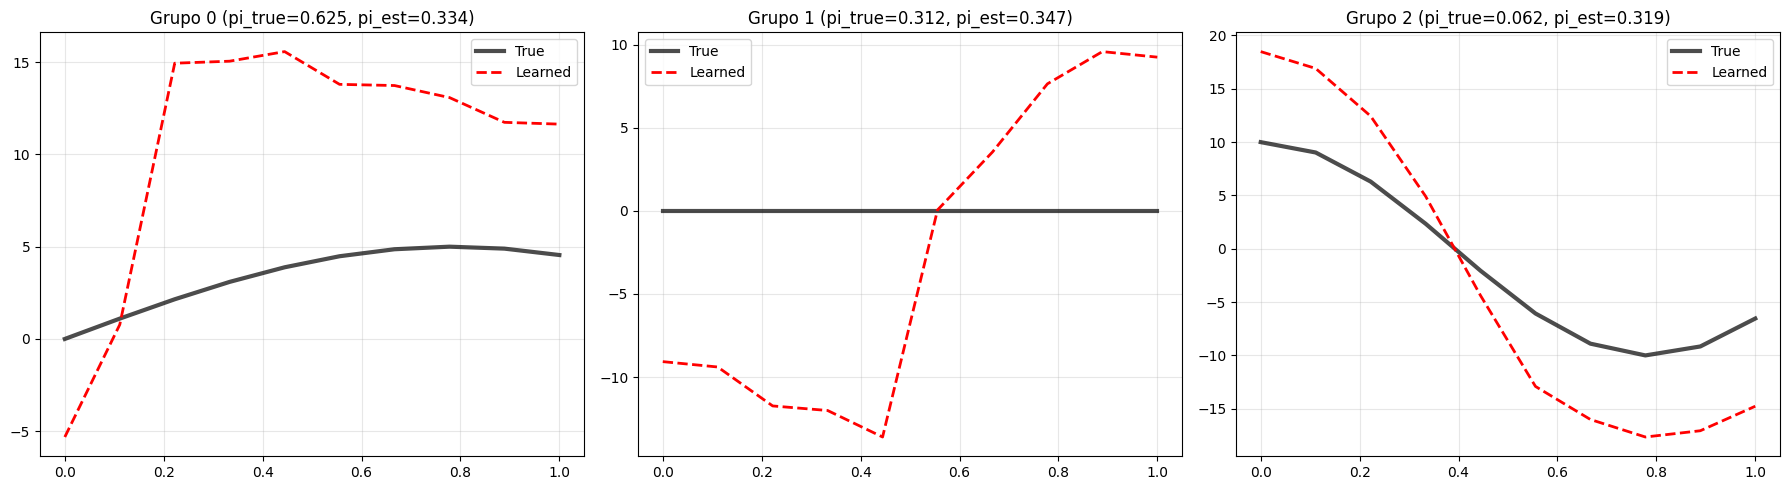

In [21]:
# Después del entrenamiento, añade:

print("\n" + "="*60)
print("DIAGNÓSTICO COMPLETO")
print("="*60)

# 1. Medias verdaderas
true_means_tensor = torch.stack([
    5*torch.sin(2*ts),
    torch.zeros(T),
    10*torch.cos(4*ts)
])

# 2. Encuentra correspondencia
from scipy.optimize import linear_sum_assignment

cost_matrix = torch.zeros((K, K))
for i in range(K):
    for j in range(K):
        cost_matrix[i, j] = torch.mean((true_means_tensor[i] - m[j])**2).item()

row_ind, col_ind = linear_sum_assignment(cost_matrix.numpy())

print("\nMejor correspondencia (True → Learned):")
for true_idx, learned_idx in zip(row_ind, col_ind):
    mse = cost_matrix[true_idx, learned_idx].item()
    print(f"  Grupo {true_idx} ↔ Componente {learned_idx} (MSE: {mse:.4f})")

# 3. Compara pi
reordered_pi = estimated_pi[col_ind]
true_pi = num/np.sum(num)

print(f"\nEstimated pi (original):  {estimated_pi}")
print(f"Estimated pi (reordered): {reordered_pi}")
print(f"True pi:                  {true_pi}")
print(f"Error absoluto:           {np.abs(reordered_pi - true_pi)}")
print(f"Error promedio:           {np.mean(np.abs(reordered_pi - true_pi)):.6f}")

# 4. Visualiza
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(K):
    axes[i].plot(ts, true_means_tensor[i].numpy(), 'k-', lw=3, label='True', alpha=0.7)
    learned_idx = col_ind[i]
    axes[i].plot(ts, m[learned_idx].detach().numpy(), 'r--', lw=2, label='Learned')
    axes[i].set_title(f'Grupo {i} (pi_true={true_pi[i]:.3f}, pi_est={reordered_pi[i]:.3f})')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()